In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing Data

In [26]:
#importing data
df = pd.read_csv("new_data.csv")

#remove histology columns
df = df.drop(columns=[
    "GP Infiltrative",
    "Gp Trabecular",
    "Gp Pseudoglandular",
    "Gp Glandular",
    "Pvh Micropapillary",
    "Pvh Adenocarcinoma",
    "Pvh Smallcell",
    "Pvh Nested",
    "Pvh Glandular",
    "Pvh Sarcomatoid",
    "Pvh Acinar",
    "Pvh Other",
    "Pvh Poorlydifferentiated",
    "Svh Poorlydifferentiated",
    "Svh Adenocarcinoma",
    "Svh Nested",
    "Svh Micropapillary",
    "Svh Sarcomatoid",
    "Svh Other",
    "Svh Glandular",
    "Svh Acinar",
    "Svh Smallcell",
    "Pvh Squamous",
    "Svh Squamous"
])

print(df.columns)
#view data
print(df.head())


#handle missing values
#check which features are missing values
print(df.isnull().sum())

#remove rows with missing values in columns with <5% of total rows missing values ("Sample Grade")
df = df.dropna(subset=["Sample Grade"])

#fill rows with unknown in columns with remaining missing values with "unknown"
df["Specimen Available"] = df["Specimen Available"].fillna("unknown")
df["BCG Instillations"] = df["BCG Instillations"].fillna("unknown")
df["Urothelial Like"] = df["Urothelial Like"].fillna("unknown")


/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_11081/3127698908.py:2: DtypeWarning: Columns (0,2,3,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,42,44,45,47,48,49,50,51,53,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("new_data.csv")


Index(['Patient_ID', 'Sample Id', 'Proteomics Id', 'Gene Of Interest',
       'TURBT Number', 'TMA Number', 'Associated CIS',
       'Muscularis Propria Present', 'LVI YN', 'Urothelial Like',
       'Sample Stage', 'Sample Grade', 'Project Use', 'Drug Type', 'BCG Type',
       'BCG Instillations', 'Treatment YN', 'Patient Dem ID',
       'Collection Type', 'Treatment Id', 'Subtype', 'Specimen Available',
       'Collection TBL ID', 'Lifetime Number Of TURBTs', 'Recurrent Tumors',
       'Sex', 'Hospital', 'Primary Diagnosis', 'Patient Age Diagnosis',
       'Diagnosis', 'Last Follow up', 'Treatment started',
       'Date of progression', 'Date of Death'],
      dtype='object')
  Patient_ID  Sample Id Proteomics Id Gene Of Interest  TURBT Number  \
0  KHSC-0058      931.0         931-T            GATA3           3.0   
1  KHSC-0059      208.0         208-T             KRT5           1.0   
2  KHSC-0060      406.0         406-S             KRT5           1.0   
3  KHSC-0061      543.0   

## Exploratory Data Analysis (EDA)

### Univariate

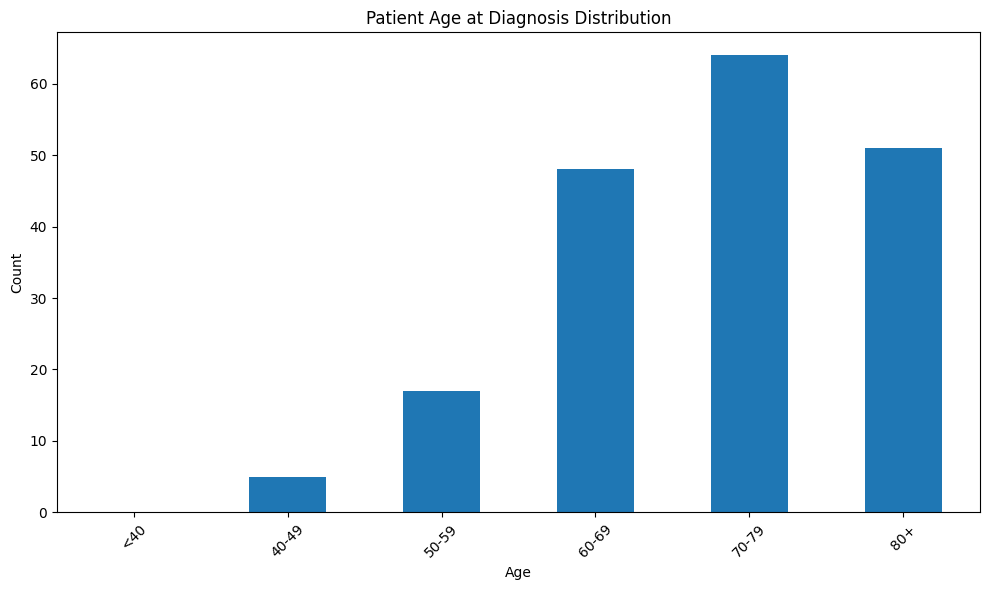

In [27]:
# patient demographics

# age
# split ages into groups
#max_age = df["Patient Age Diagnosis"].max() #might be too complicated
bins = [0, 40, 50, 60, 70, 80, 100]
labels = ["<40", "40-49", "50-59", "60-69", "70-79", "80+"]

df["Age Group"] = pd.cut(df["Patient Age Diagnosis"], bins=bins, labels=labels, right=False)

age_counts = df["Age Group"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
age_counts.plot(kind="bar")

plt.title("Patient Age at Diagnosis Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

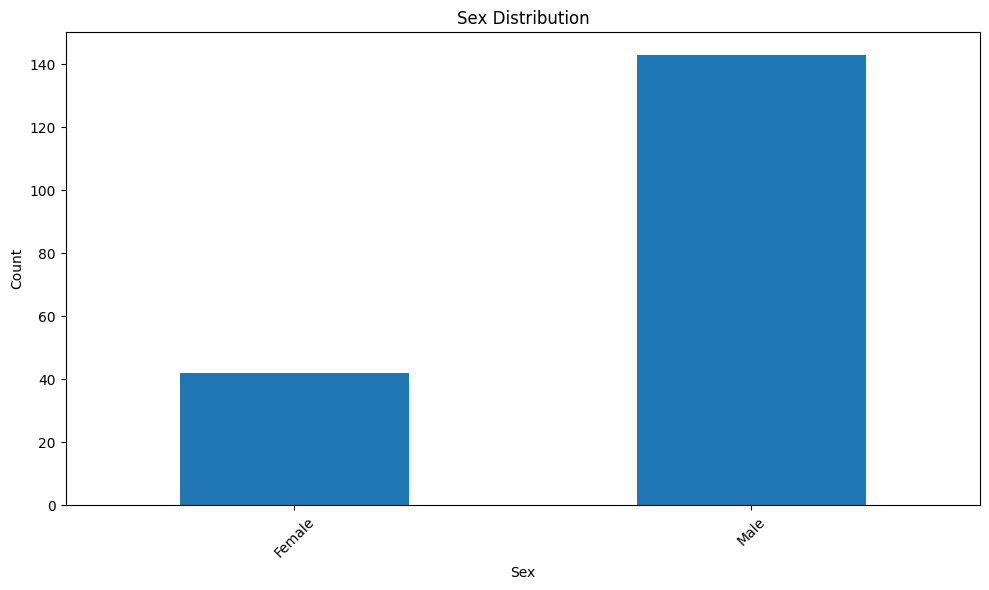

In [28]:
#sex
sex_counts = df["Sex"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sex_counts.plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

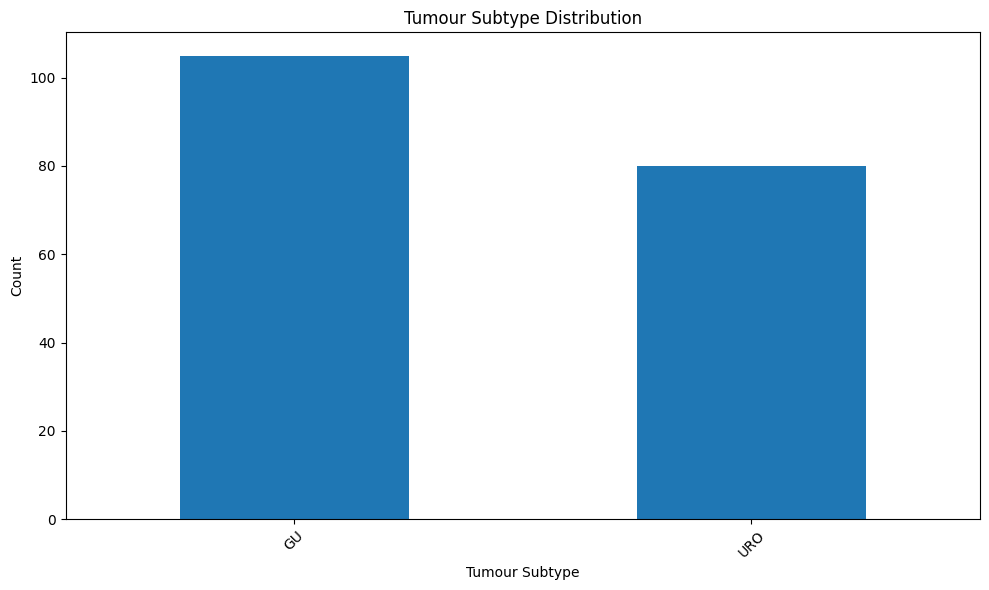

In [29]:
# tumour [statistics/insight]
# tumour subtype
subtype_counts = df["Subtype"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
subtype_counts.plot(kind="bar")

plt.title("Tumour Subtype Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

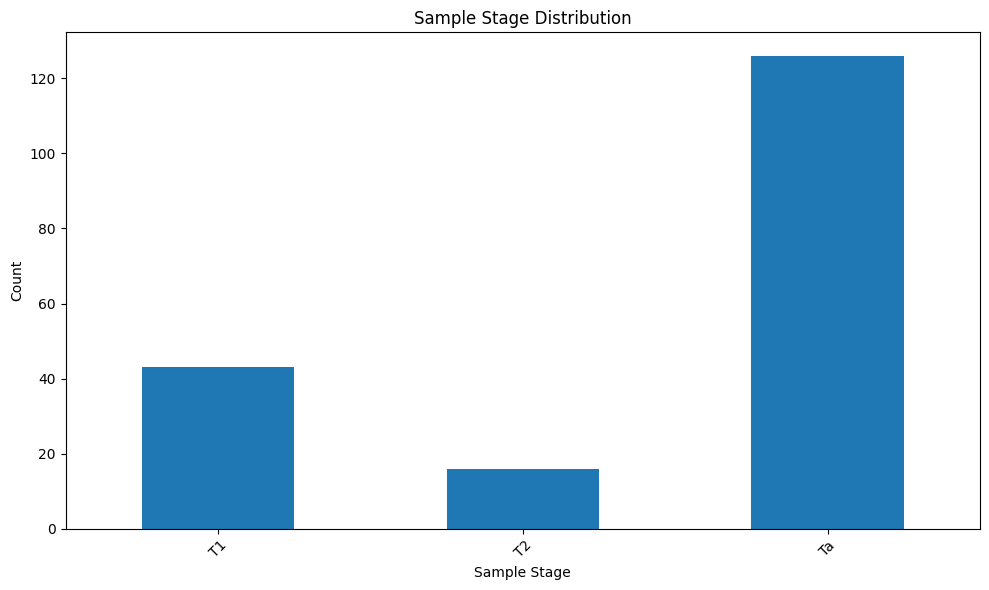

In [30]:
# sample stage
sample_stage_counts = df["Sample Stage"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sample_stage_counts.plot(kind="bar")

plt.title("Sample Stage Distribution")
plt.xlabel("Sample Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

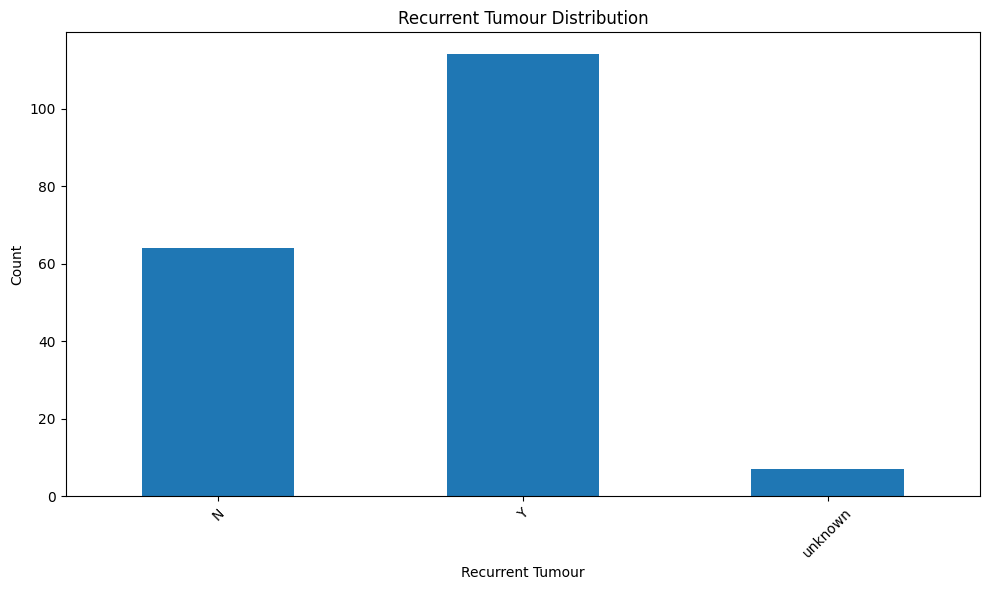

In [31]:
# recurrent tumours
sample_stage_counts = df["Recurrent Tumors"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sample_stage_counts.plot(kind="bar")

plt.title("Recurrent Tumour Distribution")
plt.xlabel("Recurrent Tumour")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Multivariate

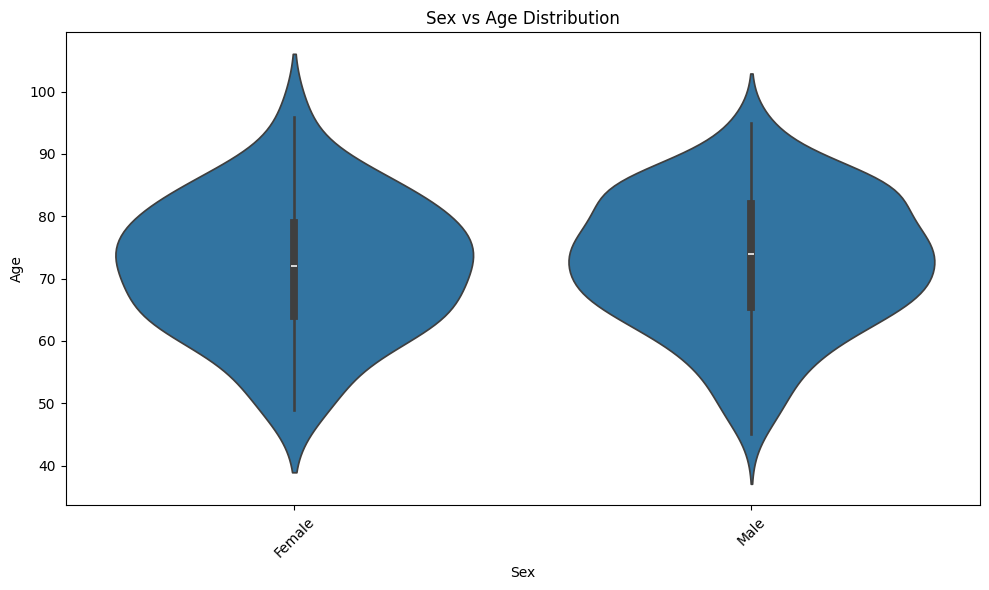

In [32]:
#age vs sex
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Sex", y="Patient Age Diagnosis")

plt.title("Sex vs Age Distribution")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

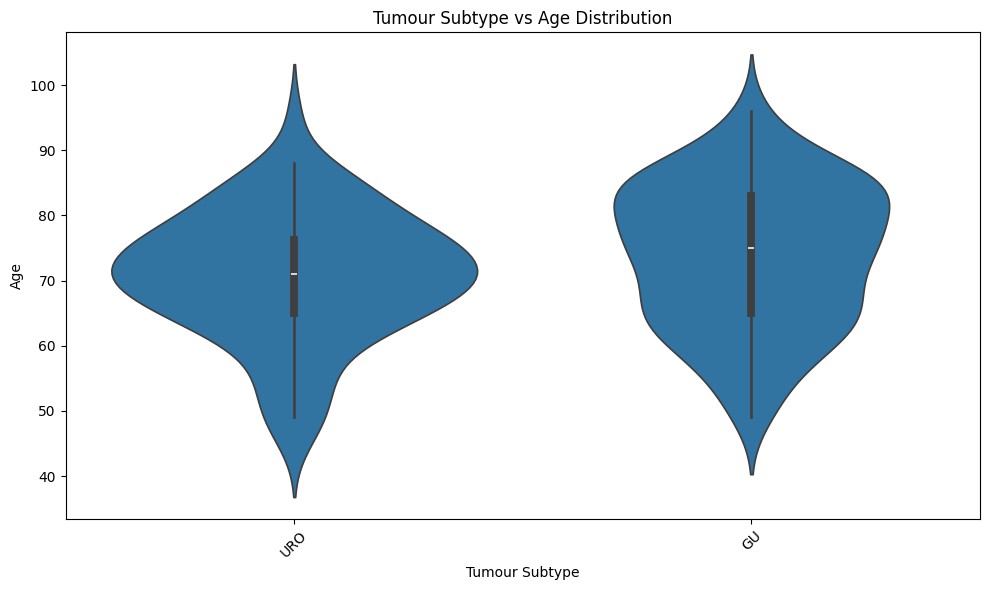

In [33]:
#tumour subtype vs age
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Subtype", y="Patient Age Diagnosis")

plt.title("Tumour Subtype vs Age Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analysis

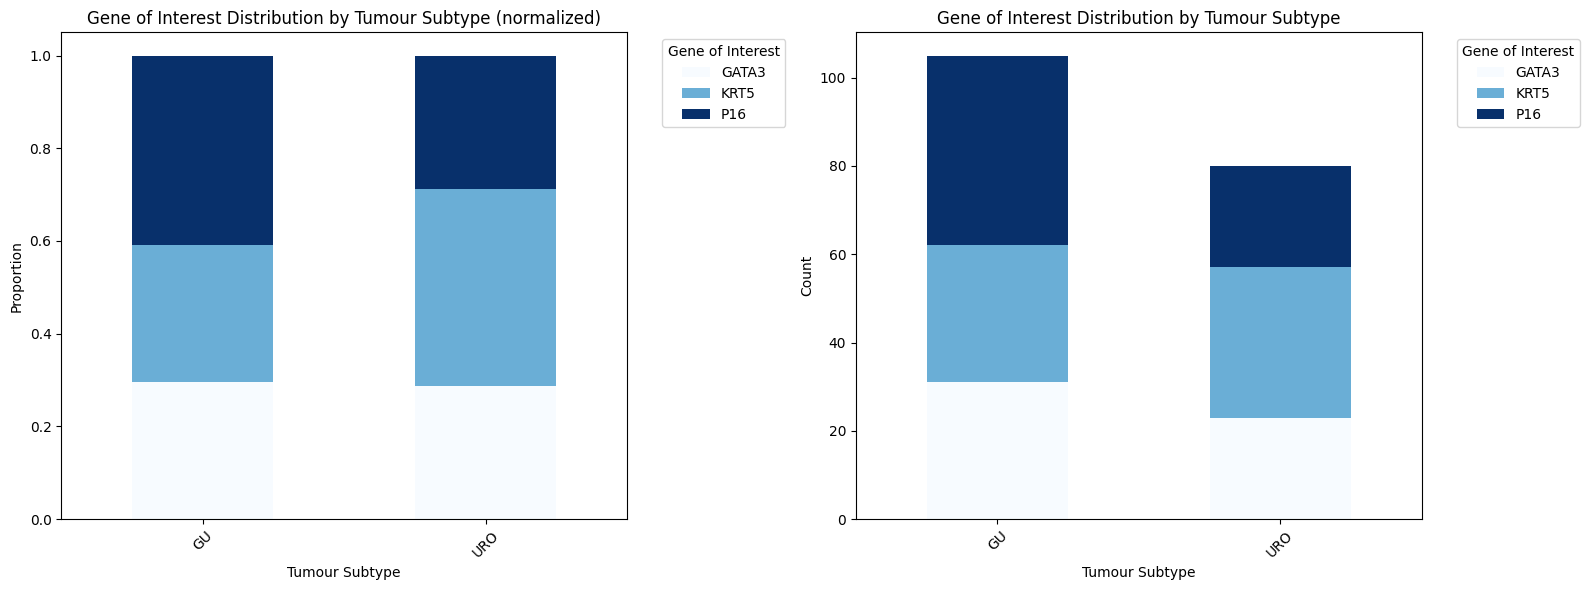

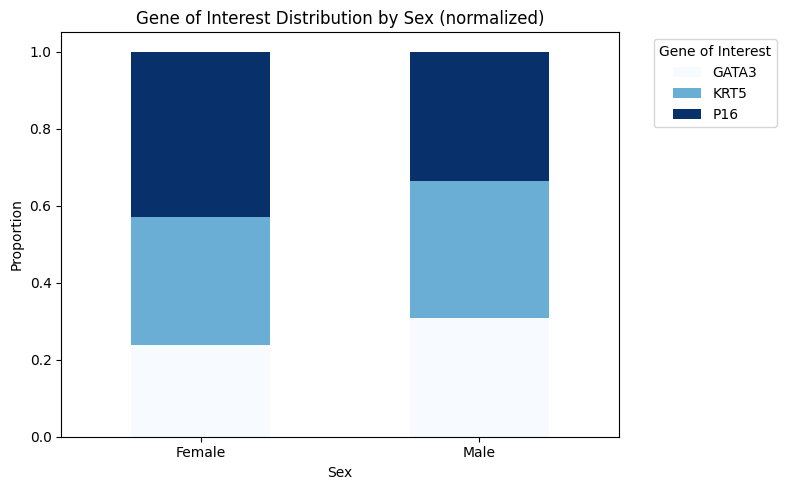

/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_11081/3015876109.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gene Of Interest", y="Patient Age Diagnosis", palette="Blues")


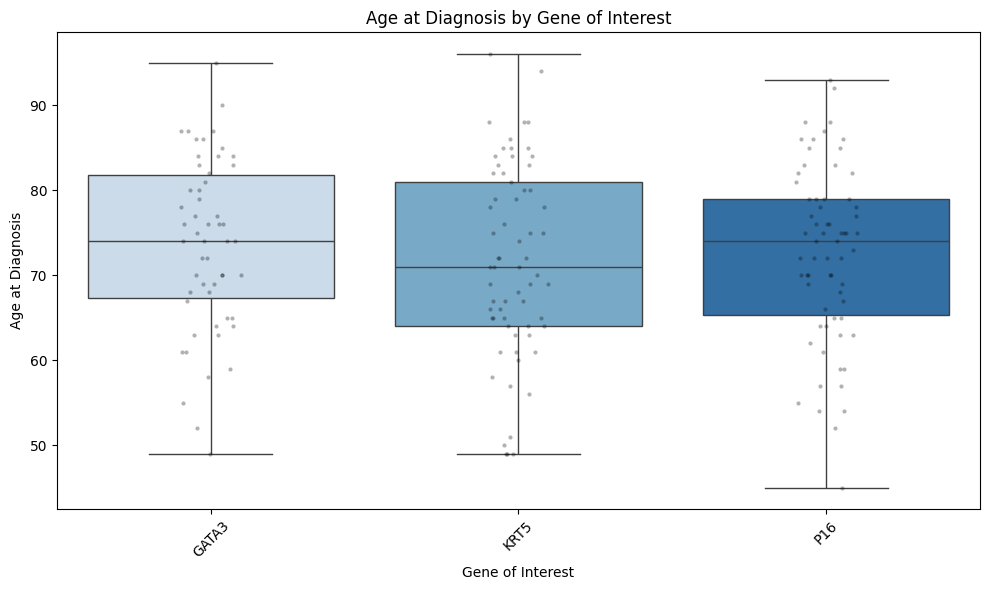

In [34]:
# Gene of Interest
 
# Gene of Interest by Tumour Subtype
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
ct = pd.crosstab(df["Subtype"], df["Gene Of Interest"])
ct_norm = ct.div(ct.sum(axis=1), axis=0) #normalize
 
ct_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("Gene of Interest Distribution by Tumour Subtype (normalized)")
axes[0].set_xlabel("Tumour Subtype")
axes[0].set_ylabel("Proportion")
axes[0].legend(title="Gene of Interest", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=45)
 
# 1b. Raw counts version for comparison
ct.plot(kind="bar", stacked=True, ax=axes[1], colormap="Blues")
axes[1].set_title("Gene of Interest Distribution by Tumour Subtype")
axes[1].set_xlabel("Tumour Subtype")
axes[1].set_ylabel("Count")
axes[1].legend(title="Gene of Interest", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()
 
 
# Gene of Interest by Sex
fig, ax = plt.subplots(figsize=(8, 5))
ct_sex = pd.crosstab(df["Sex"], df["Gene Of Interest"], normalize="index")
ct_sex.plot(kind="bar", stacked=True, ax=ax, colormap="Blues")
ax.set_title("Gene of Interest Distribution by Sex (normalized)")
ax.set_xlabel("Sex")
ax.set_ylabel("Proportion")
ax.legend(title="Gene of Interest", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
 
 
# Age distribution by Gene of Interest
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Gene Of Interest", y="Patient Age Diagnosis", palette="Blues")
sns.stripplot(data=df, x="Gene Of Interest", y="Patient Age Diagnosis",
              color="black", alpha=0.3, size=3, jitter=True)
plt.title("Age at Diagnosis by Gene of Interest")
plt.xlabel("Gene of Interest")
plt.ylabel("Age at Diagnosis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

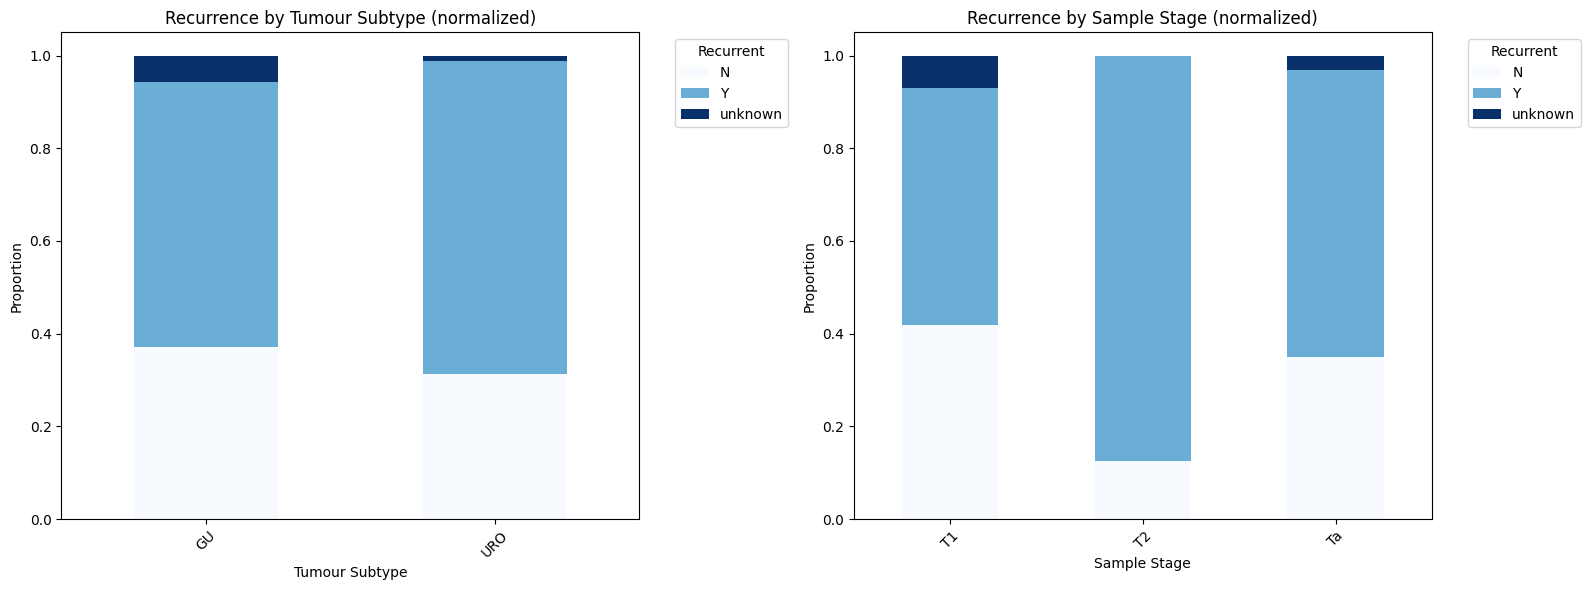

<Figure size 1000x600 with 0 Axes>

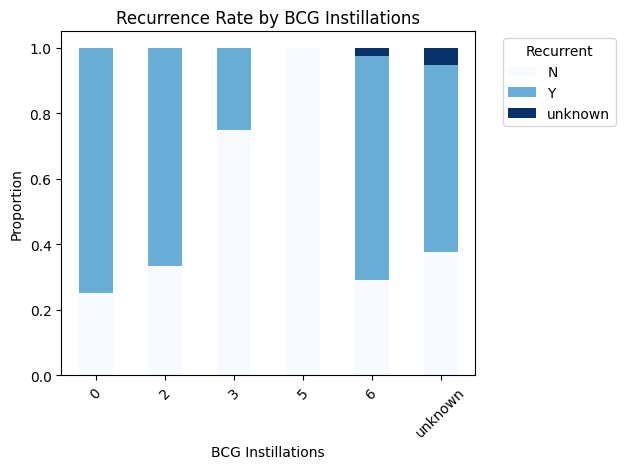

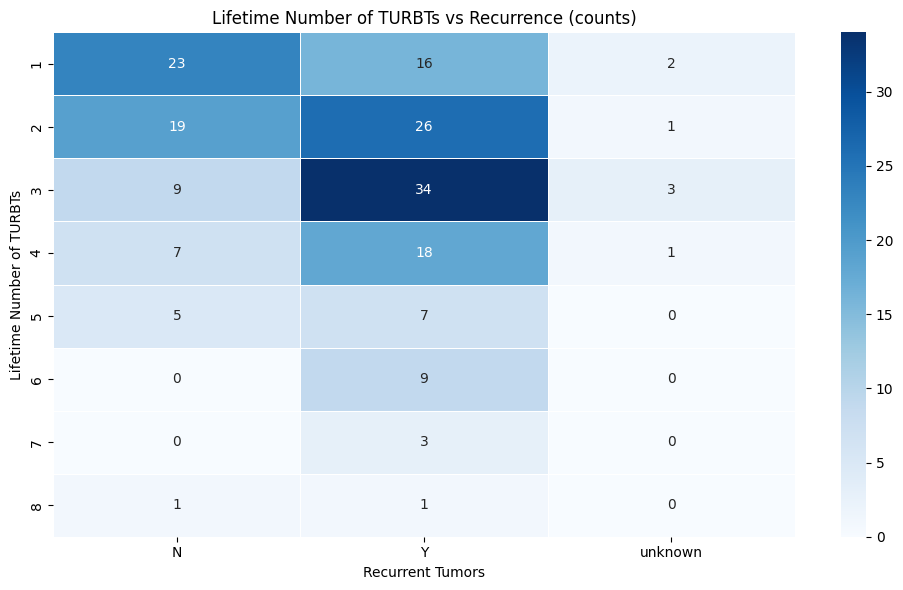

/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_11081/2289904657.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Recurrent Tumors", y="Patient Age Diagnosis",


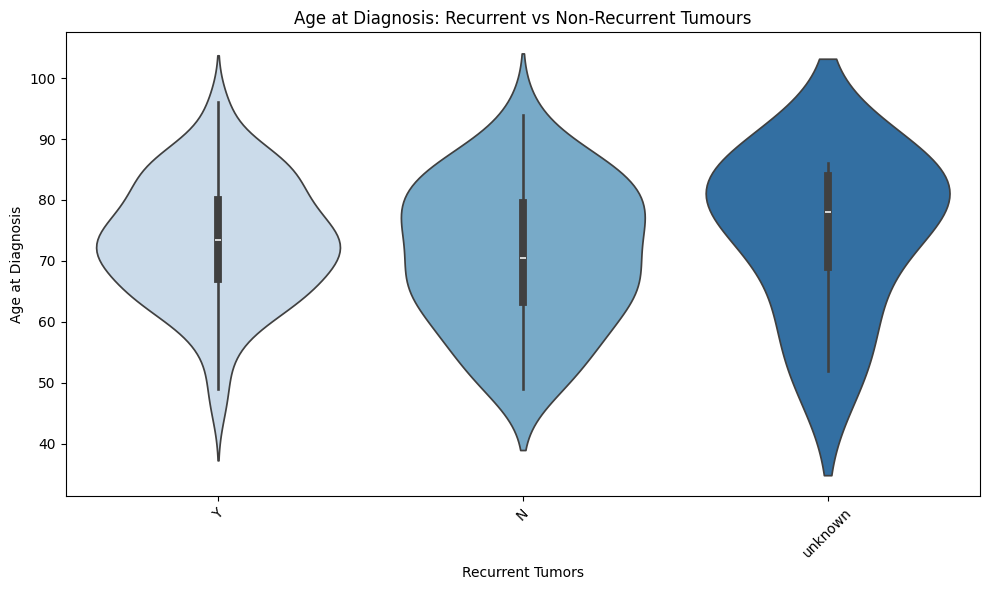

In [35]:
# Recurrence & Treatment Patterns
 
# Recurrence by Tumour Subtype
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
ct_rec = pd.crosstab(df["Subtype"], df["Recurrent Tumors"])
ct_rec_norm = ct_rec.div(ct_rec.sum(axis=1), axis=0)
 
ct_rec_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("Recurrence by Tumour Subtype (normalized)")
axes[0].set_xlabel("Tumour Subtype")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Recurrent", bbox_to_anchor=(1.05, 1), loc="upper left")
 
# Recurrence by Stage
ct_stage_rec = pd.crosstab(df["Sample Stage"], df["Recurrent Tumors"], normalize="index")
ct_stage_rec.plot(kind="bar", stacked=True, ax=axes[1], colormap="Blues")
axes[1].set_title("Recurrence by Sample Stage (normalized)")
axes[1].set_xlabel("Sample Stage")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Recurrent", bbox_to_anchor=(1.05, 1), loc="upper left")
 
plt.tight_layout()
plt.show()
 
 
# BCG Instillations vs Recurrence
plt.figure(figsize=(10, 6))
bcg_rec = pd.crosstab(df["BCG Instillations"], df["Recurrent Tumors"], normalize="index")
bcg_rec.plot(kind="bar", stacked=True, colormap="Blues")
plt.title("Recurrence Rate by BCG Instillations")
plt.xlabel("BCG Instillations")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Recurrent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
 
 
# Lifetime TURBTs vs Recurrence (heatmap)
plt.figure(figsize=(10, 6))
turbt_rec = pd.crosstab(df["Lifetime Number Of TURBTs"], df["Recurrent Tumors"])
sns.heatmap(turbt_rec, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Lifetime Number of TURBTs vs Recurrence (counts)")
plt.xlabel("Recurrent Tumors")
plt.ylabel("Lifetime Number of TURBTs")
plt.tight_layout()
plt.show()
 
 
# Age distribution — recurrent vs non-recurrent
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Recurrent Tumors", y="Patient Age Diagnosis",
               palette="Blues", inner="box")
plt.title("Age at Diagnosis: Recurrent vs Non-Recurrent Tumours")
plt.xlabel("Recurrent Tumors")
plt.ylabel("Age at Diagnosis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Survival Analysis
- Duration based on multiple dates

/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_11081/1316882543.py:4: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_11081/1316882543.py:4: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_11081/1316882543.py:4: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")


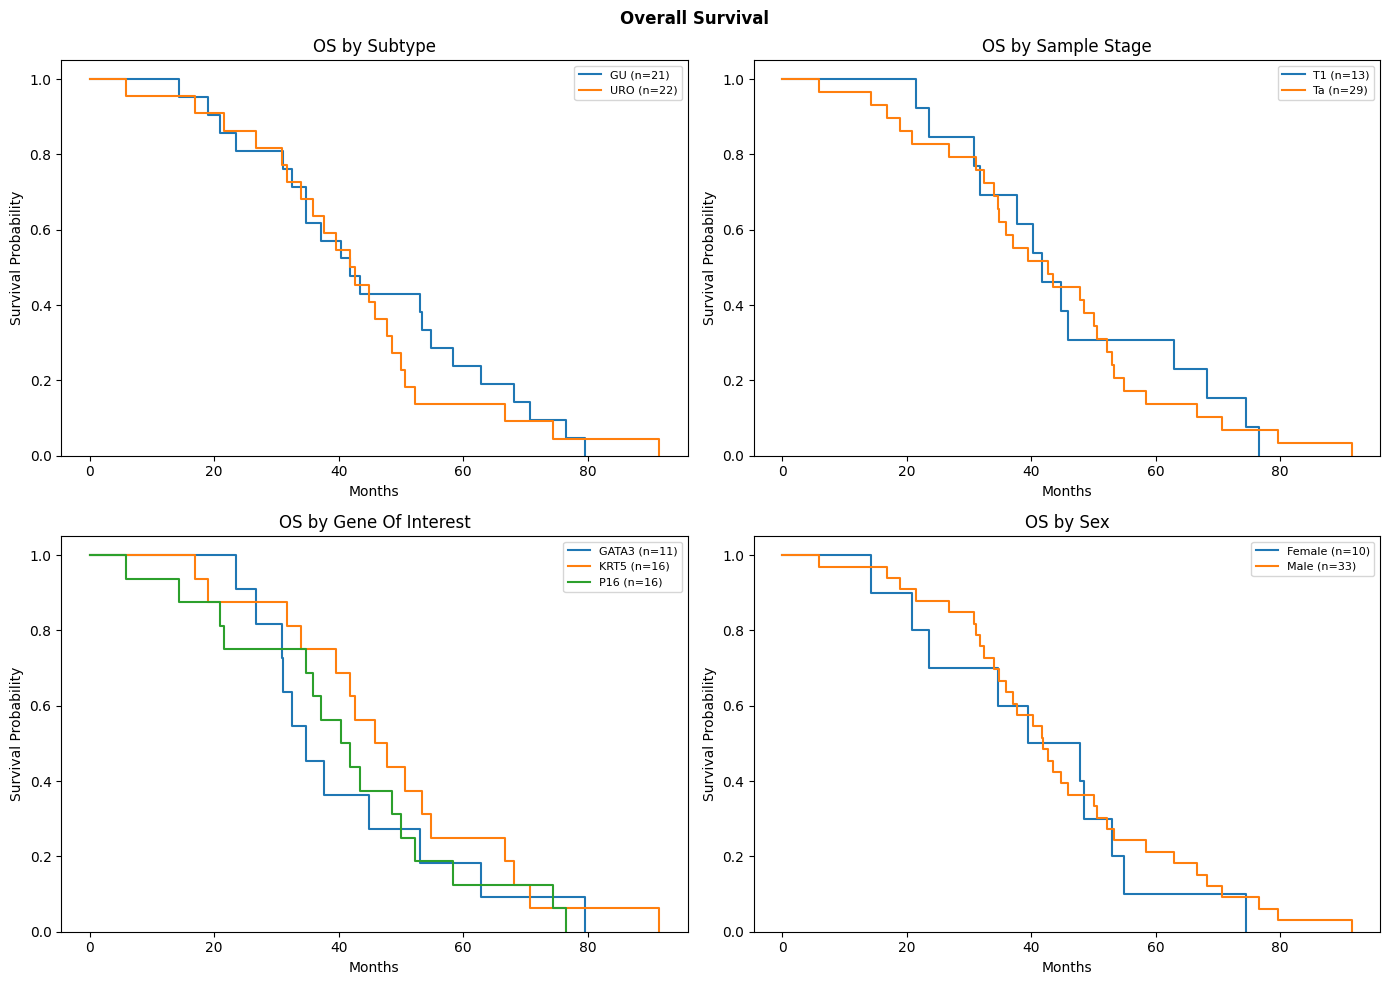

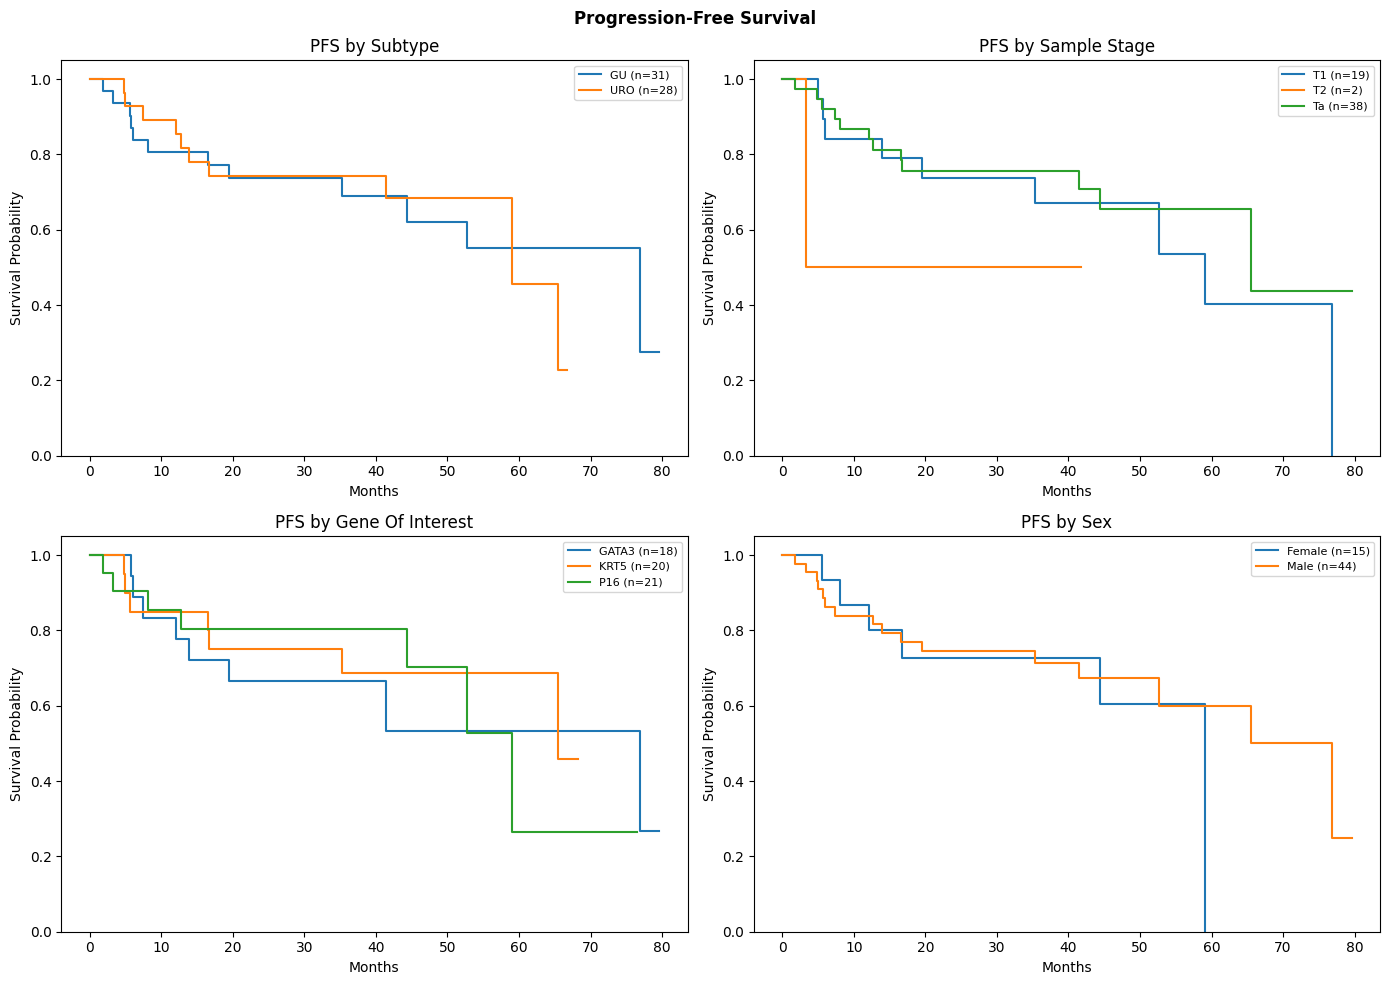

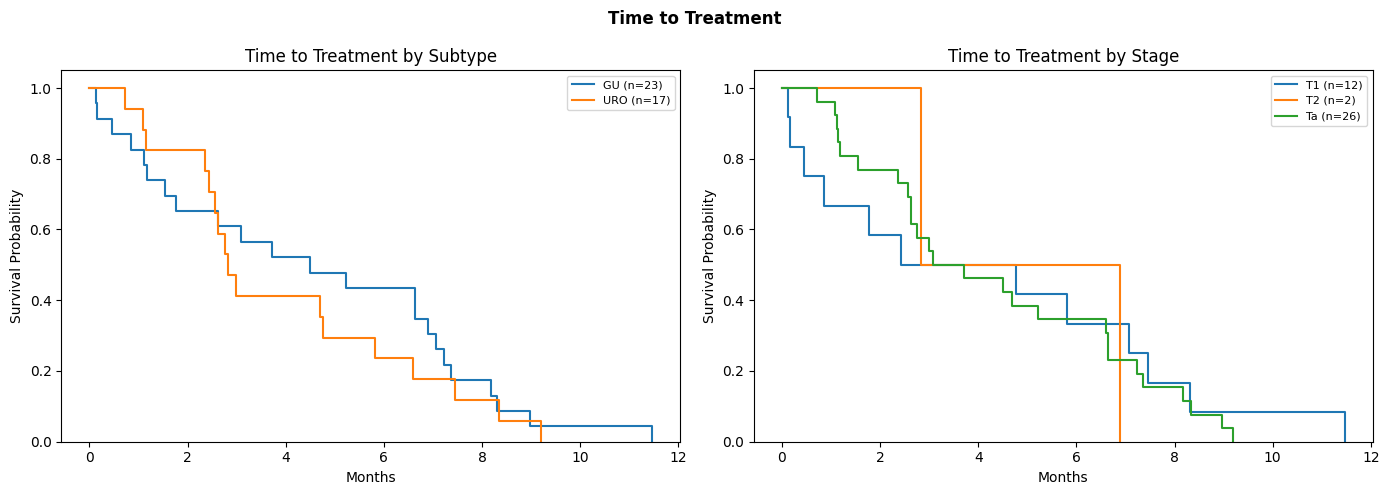

In [ ]:
from lifelines import KaplanMeierFitter
 
for col in ["Diagnosis", "Last Follow up", "Treatment started", "Date of progression"]:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")
 
df["OS_months"]    = (df["Last Follow up"]      - df["Diagnosis"]).dt.days / 30.44 #divide by average number of days in month
df["PFS_months"]   = (df["Date of progression"] - df["Diagnosis"]).dt.days / 30.44
df["TX_months"]    = (df["Treatment started"]   - df["Diagnosis"]).dt.days / 30.44
df["PFS_duration"] = df["PFS_months"].fillna(df["OS_months"])
df["OS_event"]     = df["Last Follow up"].notna().astype(int)
df["PFS_event"]    = df["Date of progression"].notna().astype(int)
 
# kaplan meier plot
 
def km_plot(df_in, duration_col, event_col, group_col, title, ax):
    kmf = KaplanMeierFitter()
    for grp in sorted(df_in[group_col].dropna().unique()):
        T = df_in.loc[df_in[group_col] == grp, duration_col].dropna()
        E = df_in.loc[T.index, event_col]
        if len(T) >= 2:
            kmf.fit(T, E, label=f"{grp} (n={len(T)})")
            kmf.plot_survival_function(ax=ax, ci_show=False)
    ax.set_title(title)
    ax.set(xlabel="Months", ylabel="Survival Probability", ylim=(0, 1.05))
    ax.legend(fontsize=8)
 
#plots 
strat_vars = ["Subtype", "Sample Stage", "Gene Of Interest", "Sex"]
 
# overall survival (OS)
df_os = df.dropna(subset=["OS_months"]).query("OS_months > 0")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flatten(), strat_vars):
    km_plot(df_os, "OS_months", "OS_event", var, f"OS by {var}", ax)
plt.suptitle("Overall Survival", fontweight="bold")
plt.tight_layout()
plt.show()
 
# progression-free survival (PFS)
df_pfs = df.dropna(subset=["PFS_duration"]).query("PFS_duration > 0")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, var in zip(axes.flatten(), strat_vars):
    km_plot(df_pfs, "PFS_duration", "PFS_event", var, f"PFS by {var}", ax)
plt.suptitle("Progression-Free Survival", fontweight="bold")
plt.tight_layout()
plt.show()
 
# time to treatment
df_tx = df.dropna(subset=["TX_months"]).query("TX_months >= 0").assign(TX_event=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
km_plot(df_tx, "TX_months", "TX_event", "Subtype",      "Time to Treatment by Subtype", axes[0])
km_plot(df_tx, "TX_months", "TX_event", "Sample Stage", "Time to Treatment by Stage",   axes[1])
plt.suptitle("Time to Treatment", fontweight="bold")
plt.tight_layout()
plt.show()
 